<a href="https://colab.research.google.com/github/madhavi-analytics/LOAN_APPROVAL_PREDICTIONS/blob/main/Loan_approval_predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_excel('/content/loan approval.xlsx')
df

,Income,Credit_Score,Loan_Amount,Loan_Term,Existing_Loans,Dependents,Loan_Approved
0,118725,312,45056,83,4,2,0
1,123844,405,8203,321,3,4,0
2,111321,674,7244,265,2,1,1
3,69056,398,37786,173,4,1,0
4,83851,491,8083,338,0,1,1
...,...,...,...,...,...,...,...
495,22795,815,21378,134,2,3,0
496,117462,696,5678,240,3,2,1
497,65264,405,35640,93,1,1,0
498,122892,384,38756,155,2,0,0


In [ ]:
df.shape

(500, 7)

In [ ]:
df.size

3500

In [ ]:
df.describe ()

,Income,Credit_Score,Loan_Amount,Loan_Term,Existing_Loans,Dependents,Loan_Approved
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000
mean,85572.10000,572.758000,27767.036000,178.312000,1.922000,1.96600,0.508000
std,37348.03626,161.925338,12805.227397,101.105823,1.417015,1.39166,0.500437
min,20066.00000,300.000000,5402.000000,12.000000,0.000000,0.00000,0.000000
25%,54855.50000,428.750000,16925.500000,89.750000,1.000000,1.00000,0.000000
50%,86702.00000,570.000000,27512.000000,176.500000,2.000000,2.00000,1.000000
75%,117686.75000,723.250000,38653.750000,265.250000,3.000000,3.00000,1.000000
max,149045.00000,849.000000,49980.000000,359.000000,4.000000,4.00000,1.000000


In [ ]:
df.isnull().sum()

,0
Income,0
Credit_Score,0
Loan_Amount,0
Loan_Term,0
Existing_Loans,0
Dependents,0
Loan_Approved,0


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
495,False
496,False
497,False
498,False


In [ ]:
df.head()

,Income,Credit_Score,Loan_Amount,Loan_Term,Existing_Loans,Dependents,Loan_Approved
0,118725,312,45056,83,4,2,0
1,123844,405,8203,321,3,4,0
2,111321,674,7244,265,2,1,1
3,69056,398,37786,173,4,1,0
4,83851,491,8083,338,0,1,1


In [ ]:
from sklearn.model_selection import (train_test_split,cross_val_score)
from sklearn.tree import ( DecisionTreeClassifier, plot_tree)

from sklearn.ensemble import (RandomForestClassifier)

from sklearn.metrics import (accuracy_score,classification_report, confusion_matrix)

Features and target

In [ ]:

X = df.drop('Loan_Approved', axis=1)
y = df['Loan_Approved']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

Decision tree model

In [ ]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, pred))

Decision Tree Accuracy: 0.43


Random forest model

In [ ]:
d_model = RandomForestClassifier( n_estimators=100,random_state=42)

d_model.fit(X_train, y_train)

d_pred =d_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, d_pred))

Random Forest Accuracy: 0.5


In [ ]:
from sklearn.linear_model import LogisticRegression
f_model = LogisticRegression()
f_model.fit(X_train, y_train)
f_pred =f_model.predict(X_test)

print('Logistic accuracy:',accuracy_score(y_test, f_pred))

Logistic accuracy: 0.51


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Feature importance ranking

In [ ]:
importance = d_model.feature_importances_

feature_importance = pd.DataFrame({'Feature': X.columns,'Importance': importance})

feature_importance = feature_importance.sort_values(by='Importance',ascending=False)

print(feature_importance)

          Feature  Importance
2     Loan_Amount    0.223456
3       Loan_Term    0.210287
1    Credit_Score    0.207797
0          Income    0.199256
4  Existing_Loans    0.080774
5      Dependents    0.078430


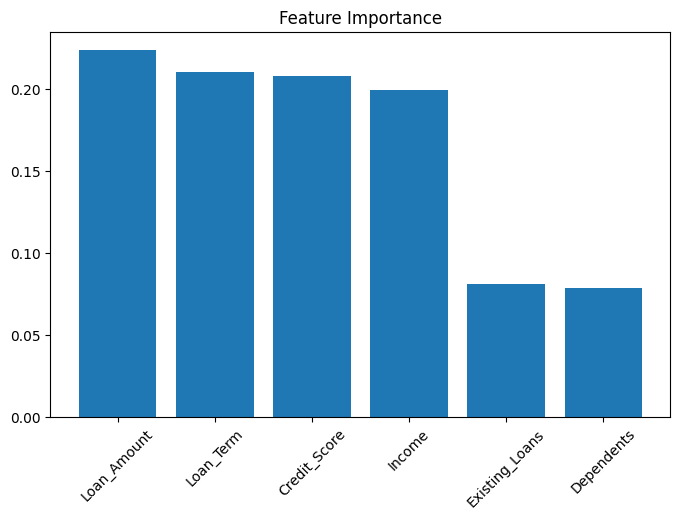

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.bar(feature_importance['Feature'],feature_importance['Importance'])

plt.xticks(rotation=45)

plt.title('Feature Importance')

plt.show()

In [ ]:
import joblib
joblib.dump(f_model, 'model.pkl')

['model.pkl']

In [ ]:
!pip install streamlit pyngrok
!streamlit run app.py &>/dev/null &

In [ ]:
import streamlit as st
import joblib

model = joblib.load("model.pkl")

st.title("Loan Approval Prediction")

income = st.number_input("Income")
credit = st.number_input("Credit Score")
loan = st.number_input("Loan Amount")
term = st.number_input("Loan Term")
existing = st.number_input("Existing Loans")
dependents = st.number_input("Dependents")

if st.button("Predict"):
    prediction = model.predict([
        [income, credit, loan, term, existing, dependents]
    ])

    if prediction[0] == 1:
        st.success("Loan Approved ✅")
    else:
        st.error("Loan Not Approved ❌")

2026-06-07 16:38:10.974 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:38:10.979 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:38:10.981 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:38:10.983 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:38:10.987 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:38:10.989 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:38:10.990 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:38:10.993 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
%%writefile requirements.txt

streamlit
scikit-learn
joblib
numpy
pandas

Writing requirements.txt
